# Cognifyz Internship
# Level 3
# Task 2: Customer Preference Analysis
Analyze the relationship between the type of cuisine and the restaurant's rating.Identify the most popular cuisines among customers based on the number of votes.Determine if there are any specific cuisines that tend to receive higher ratings.

## 1. Importing necesary libraries

In [873]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Loading dataset

In [876]:
df=pd.read_csv("data.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## 3. EDA and Preprocessing

In [879]:
df.info()                                        # Gives basic information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [881]:
df.shape                                          # 9551 no of rows and 21 columns are there in the dataset 

(9551, 21)

In [883]:
df.dtypes                                      # Displays datatype of fields 

Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

In [885]:
df.describe()                                  # Gives statistical summary of numerical features

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [887]:
df.nunique()                               # Gives the countof unique value in each column

Restaurant ID           9551
Restaurant Name         7446
Country Code              15
City                     141
Address                 8918
Locality                1208
Locality Verbose        1265
Longitude               8120
Latitude                8677
Cuisines                1825
Average Cost for two     140
Currency                  12
Has Table booking          2
Has Online delivery        2
Is delivering now          2
Switch to order menu       1
Price range                4
Aggregate rating          33
Rating color               6
Rating text                6
Votes                   1012
dtype: int64

In [889]:
df.isnull().sum()                                   # Check for null values in each field

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [891]:
df['Cuisines']=df['Cuisines'].fillna(df['Cuisines'].mode()[0])        # Null value in the field 'Cuisine'is imputed with mode value

In [893]:
df.isnull().sum()                                                    # Rechecking for null values

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [895]:
df.duplicated().sum()                                      # Checking for duplicate values

0

In [897]:
for col in df.select_dtypes(include='object'):                              # Removing non printable characters from the dataset
    df[col]=df[col].str.replace(r'[^a-zA-Z0-9, ]+','',regex=True)

In [898]:
df['Cuisines'].value_counts()                                         

Cuisines
North Indian                                             945
North Indian, Chinese                                    511
Chinese                                                  354
Fast Food                                                354
North Indian, Mughlai                                    334
                                                        ... 
Bengali, Fast Food                                         1
North Indian, Rajasthani, Asian                            1
Chinese, Thai, Malaysian, Indonesian                       1
Bakery, Desserts, North Indian, Bengali, South Indian      1
Italian, World Cuisine                                     1
Name: count, Length: 1825, dtype: int64

In [901]:
df['Cuisines']=df['Cuisines'].str.split(',')             # Splitting cuisine which is stored as single string
df=df.explode('Cuisines')                                # Creating separate row for each cuisine
df['Cuisines'] = df['Cuisines'].str.strip()              # Removing any leading or trailing space

In [903]:
df['Cuisines'].value_counts()

Cuisines
North Indian      3969
Chinese           2735
Fast Food         1986
Mughlai            995
Italian            764
                  ... 
Fish and Chips       1
Malwani              1
Cuisine Varies       1
Mineira              1
Brek                 1
Name: count, Length: 145, dtype: int64

In [905]:
df['Aggregate rating'].value_counts()

Aggregate rating
0.0    3443
3.4    1095
3.5    1079
3.2    1053
3.6    1044
3.3    1018
3.7     979
3.8     972
3.1     971
3.0     857
3.9     856
2.9     710
2.8     663
4.0     659
4.1     648
4.2     558
2.7     541
2.6     419
4.3     412
4.4     370
2.5     265
4.5     227
2.4     205
4.6     186
4.9     116
2.3     100
4.7      98
2.2      58
4.8      52
2.1      40
2.0      17
1.9       6
1.8       2
Name: count, dtype: int64

In [907]:
df=df[df['Aggregate rating']!=0]     # Aggregate rating with value 0 is removed as objective of task is to predict aggregate rating and target value with 0 is not useful.

## Five most popular cuisines based on votes

In [910]:
top5=df.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False).reset_index().head() # Grouping 'Cuisine' based on vote in descending order
top5

,Cuisines,Votes
0,North Indian,597920
1,Chinese,363890
2,Italian,329230
3,Continental,288213
4,Fast Food,183665


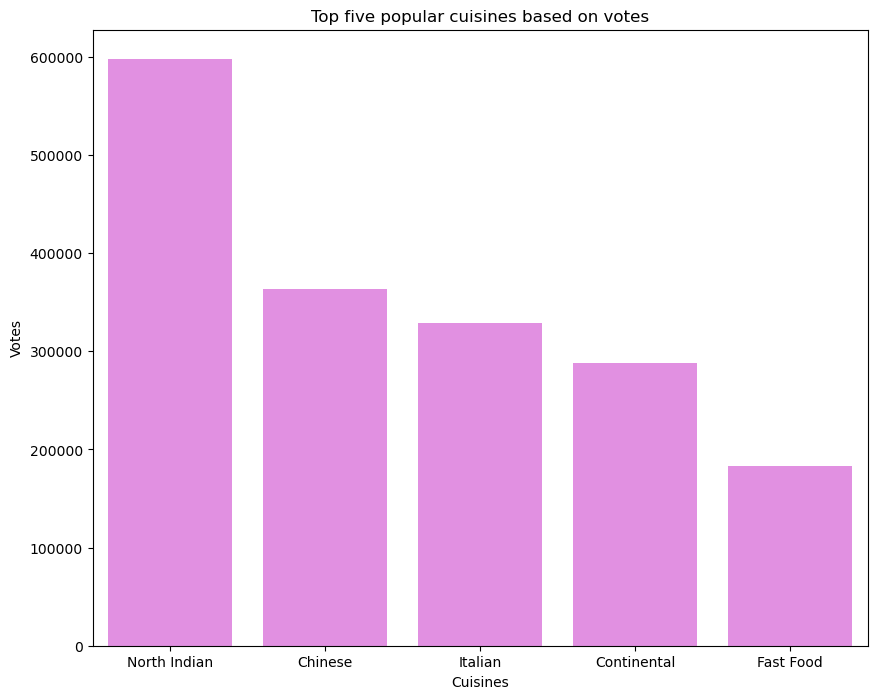

In [912]:
plt.figure(figsize=(10,8))                                       # Visulaisation of top 5 popular cuisines based on vote
sns.barplot(data=top5,x='Cuisines',y='Votes',color='violet')
plt.title("Top five popular cuisines based on votes")
plt.show()

Comment :
- Majority of the customers have voted for North Indian dishes.
- Chiness and Italian Cuisines holds next two positions.
- This could be due to availabilty of North Indian dishes all over the World.

## Highly rated cuisines

In [916]:
relation=df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).reset_index().head()
relation                                                                     # Grouped'Cuisine' based on aggregate rating mean and sorted 

,Cuisines,Aggregate rating
0,Sunda,4.90
1,Brek,4.70
2,Taiwanese,4.65
3,Persian,4.60
4,Ramen,4.50


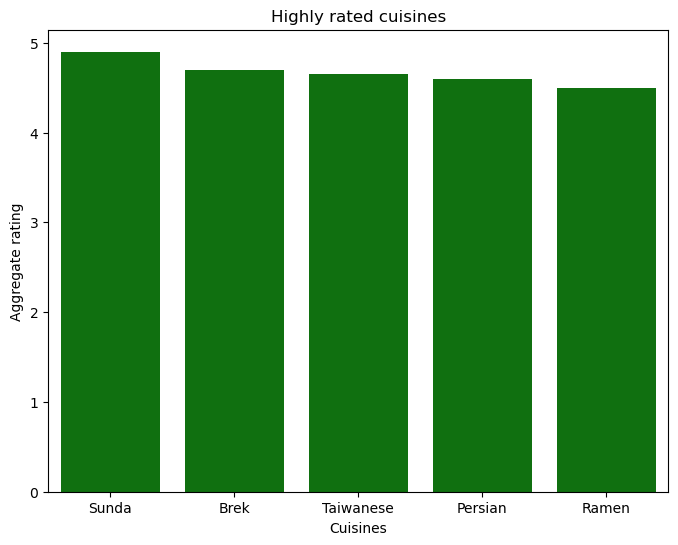

In [918]:
plt.figure(figsize=(8,6))                                                        # Visualisation of highly rated cuisine
sns.barplot(data=relation,x='Cuisines',y='Aggregate rating',color='green')
plt.title("Highly rated cuisines")
plt.show()

Comment :
- Customer have highly rated the dish Sunda.
- Brek and Taiwanese Cuisines comes next in line.


## Relation between the type of cuisine and the restaurant's rating

In [922]:
def cuisine_list(cuisines):
    
    if cuisines.lower() in (['indian','northindian','southindian','mughlai','biryani','hyderabadi',
    'rajasthani','goan','gujarati','maharashtrian','modernindian','chettinad','parsi','kerala','kashmiri','bengali',
    'lucknowi','awadhi','oriya','bihari','assamese','andhra','mangalorean','malwani','naga','mithai','curry','vegetarian','northeastern']):
        return "Indian"
    
    elif cuisines.lower() in (['japanese','filipino','sushi','korean','chinese','asian','vietnamese','thai','teriyaki','singaporean','malay',
    'cantonese','dimsum','indonesian','burmese','tibetan','nepalese','srilankan','peranakan','sunda','ramen','taiwanese','asianfusion']):
         return "Asian"

    elif cuisines.lower() in (['arabian','lebanese','middleeastern','turkish','persian','iranian','moroccan','afghani','pakistani',
    'african','southafrican','durban','kebab','turkishpizza','izgara']):
        return "Middle_east"
    elif cuisines.lower() in (['french','italian','pizza','mediterranean','spanish','german','greek','continental','british',
    'portuguese','armenian','belgian','scottish','irish','patisserie','fishandchips']):
        return "European"

    elif cuisines.lower() in (['mexican','american','brazilian','peruvian','latinamerican','argentine','caribbean','cajun','canadian',
    'texmex','australian','modernaustralian','kiwi','cuban','hawaiian','newamerican','soulfood','southern','southwestern','western']):
         return "Western"

    else:
        return "Others"


In [924]:
df['Cuisines']=df['Cuisines'].apply(cuisine_list)

In [926]:
df=pd.get_dummies(df,columns=['Cuisines'],drop_first=True)

In [928]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Average Cost for two,...,Price range,Aggregate rating,Rating color,Rating text,Votes,Cuisines_European,Cuisines_Indian,Cuisines_Middle_east,Cuisines_Others,Cuisines_Western
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,1100,...,3,4.8,Dark Green,Excellent,314,True,False,False,False,False
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,1100,...,3,4.8,Dark Green,Excellent,314,False,False,False,False,False
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,1100,...,3,4.8,Dark Green,Excellent,314,False,False,False,True,False
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,1200,...,3,4.5,Dark Green,Excellent,591,False,False,False,False,False
2,6300002,Heat Edsa ShangriLa,162,Mandaluyong City,"Edsa ShangriLa, 1 Garden Way, Ortigas, Mandalu...","Edsa ShangriLa, Ortigas, Mandaluyong City","Edsa ShangriLa, Ortigas, Mandaluyong City, Man...",121.056831,14.581404,4000,...,4,4.4,Green,Very Good,270,False,False,False,True,False


In [930]:
corr_feature=['Cuisines_European','Cuisines_Indian','Cuisines_Middle_east','Cuisines_Others','Cuisines_Western','Aggregate rating']
df[corr_feature].head()

,Cuisines_European,Cuisines_Indian,Cuisines_Middle_east,Cuisines_Others,Cuisines_Western,Aggregate rating
0,True,False,False,False,False,4.8
0,False,False,False,False,False,4.8
0,False,False,False,True,False,4.8
1,False,False,False,False,False,4.5
2,False,False,False,True,False,4.4


In [932]:
correlation=df[corr_feature].corr()
correlation

,Cuisines_European,Cuisines_Indian,Cuisines_Middle_east,Cuisines_Others,Cuisines_Western,Aggregate rating
Cuisines_European,1.000000,-0.117116,-0.035728,-0.413435,-0.077292,0.152922
Cuisines_Indian,-0.117116,1.000000,-0.030492,-0.352845,-0.065965,-0.056699
Cuisines_Middle_east,-0.035728,-0.030492,1.000000,-0.107639,-0.020123,0.052557
Cuisines_Others,-0.413435,-0.352845,-0.107639,1.000000,-0.232863,-0.108525
Cuisines_Western,-0.077292,-0.065965,-0.020123,-0.232863,1.000000,0.144496
Aggregate rating,0.152922,-0.056699,0.052557,-0.108525,0.144496,1.000000


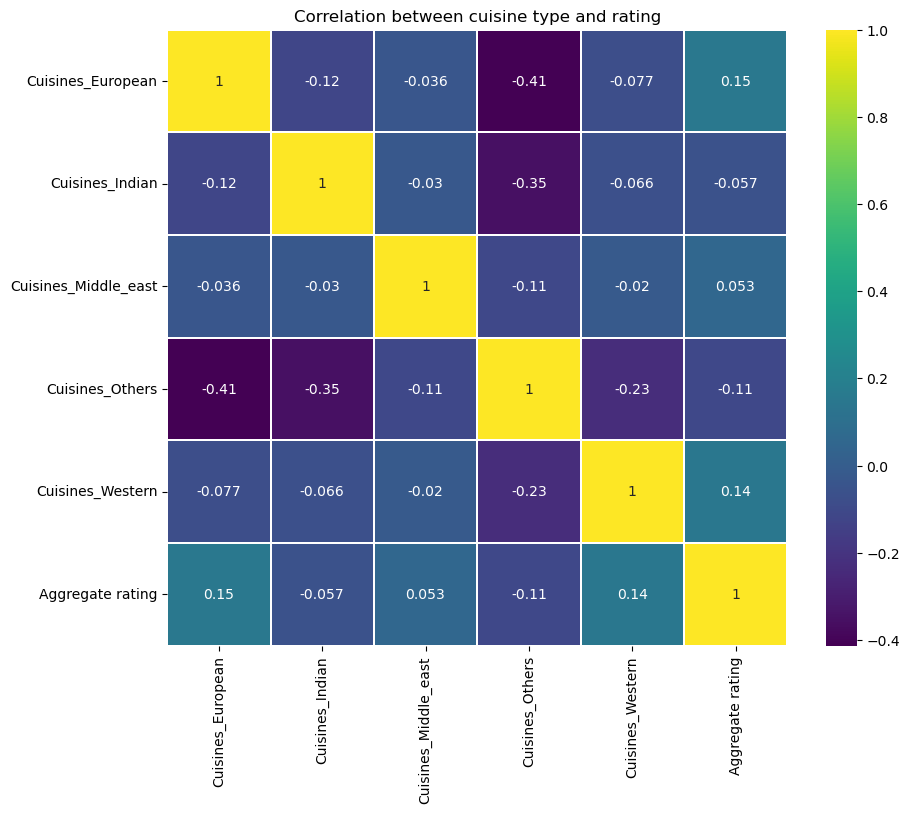

In [934]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation,annot=True,linewidth=0.2,fmt='0.2g',cmap='viridis')
plt.title("Correlation between cuisine type and rating")
plt.show()

Comment:
- There is no strong correlation exist between type of cuisine and rating.


Conclusion:

- Majority of the customers have voted for North Indian dishes.
- This could be due to availabilty of North Indian dishes all over the World.
- Sunda has received the highest rating.
- Popular dishes got highest votes but not highest rating. This could be due to :
    - Customers tend to order these cuisines frequently because they are well-known and widely available even if the experience isn’t always exceptional.
    - Customer might not have rated.
    - Popular dishes are offered by large number of restaurant that increases vote but quality across may lower rating.